In [77]:
# [1] Load libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# [2] Load datasets
orders = pd.read_csv("olist_orders_dataset (3).csv")
order_items = pd.read_csv("olist_order_items_dataset (2).csv")
products = pd.read_csv("olist_products_dataset (1).csv")
reviews = pd.read_csv("olist_order_reviews_dataset (2).csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

#  [3] Parse date columns
date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [78]:
# [4] Merge the 5 tables into one analytical dataset
# Key joins: order_id (orders <-> order_items <-> reviews) and product_id (order_items <-> products)
 
df = order_items.merge(orders, on="order_id", how="left")
df = df.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
df = df.merge(category_translation, on="product_category_name", how="left")
 
# reviews: an order can have multiple review rows (rare) -> take mean review_score per order first
review_scores = reviews.groupby("order_id", as_index=False)["review_score"].mean()
df = df.merge(review_scores, on="order_id", how="left")
 
print("Merged dataset shape:", df.shape)
df.head()
 
#  [5] Filter to delivered orders only
df = df[df["order_status"] == "delivered"].copy()
print(f"Delivered rows: {len(df):,}")

Merged dataset shape: (112650, 17)
Delivered rows: 110,197


In [79]:
# [6] Feature engineering: delivery time, order month, fill missing category
df["delivery_time_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days
 
# Delay vs estimate (negative = delivered early, positive = late)
df["delivery_delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days
 
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)
 
df["product_category_name_english"] = df["product_category_name_english"].fillna("unknown")
 
# Revenue per line item = price (freight excluded from "Revenue" KPI; using item price)
df["revenue"] = df["price"]
 
df[["order_id", "product_category_name_english", "revenue",
    "delivery_time_days", "review_score", "order_month"]].head()
 

,order_id,product_category_name_english,revenue,delivery_time_days,review_score,order_month
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,58.90,7.00,5.00,2017-09
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,239.90,16.00,4.00,2017-04
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,199.00,7.00,5.00,2018-01
3,00024acbcdf0a6daa1e931b038114c75,perfumery,12.99,6.00,4.00,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,199.90,25.00,5.00,2017-02


In [80]:

#  [7] Core KPI #1-4: Overall KPIs
total_revenue = df["revenue"].sum()
aov = df.groupby("order_id")["revenue"].sum().mean()
avg_delivery_time = df["delivery_time_days"].mean()
avg_review_score = df["review_score"].mean()
 
print(f"KPI 1 - Total Revenue:        {total_revenue:,.2f} BRL")
print(f"KPI 2 - Avg Order Value (AOV):  {aov:,.2f} BRL")
print(f"KPI 3 - Avg Delivery Time:      {avg_delivery_time:,.2f} days")
print(f"KPI 4 - Avg Review Score:       {avg_review_score:,.2f} / 5")
 
#  [8] KPIs by product category (English name)
category_kpis = df.groupby("product_category_name_english").agg(
    Revenue=("revenue", "sum"),
    Orders=("order_id", "nunique"),
    Avg_Delivery_Time=("delivery_time_days", "mean"),
    Avg_Review_Score=("review_score", "mean")
).reset_index()
 
category_kpis["AOV"] = category_kpis["Revenue"] / category_kpis["Orders"]
category_kpis = category_kpis.round(2).sort_values("Revenue", ascending=False)
 
category_kpis.head(10)
 
# [9] KPIs by month
monthly_kpis = df.groupby("order_month").agg(
    Revenue=("revenue", "sum"),
    Orders=("order_id", "nunique"),
    Avg_Delivery_Time=("delivery_time_days", "mean"),
    Avg_Review_Score=("review_score", "mean")
).reset_index()
 
monthly_kpis["AOV"] = monthly_kpis["Revenue"] / monthly_kpis["Orders"]
monthly_kpis = monthly_kpis.round(2).sort_values("order_month")
 
monthly_kpis

KPI 1 - Total Revenue:        13,221,498.11 BRL
KPI 2 - Avg Order Value (AOV):  137.04 BRL
KPI 3 - Avg Delivery Time:      12.01 days
KPI 4 - Avg Review Score:       4.08 / 5


,order_month,Revenue,Orders,Avg_Delivery_Time,Avg_Review_Score,AOV
0,2016-09,134.97,1,54.00,1.00,134.97
1,2016-10,"40,325.11",265,19.12,3.90,152.17
2,2016-12,10.90,1,4.00,5.00,10.90
3,2017-01,"111,798.36",750,12.09,4.16,149.06
4,2017-02,"234,223.40",1653,12.61,4.18,141.70
5,2017-03,"359,198.85",2546,12.42,4.14,141.08
6,2017-04,"340,669.68",2303,14.28,4.10,147.92
7,2017-05,"489,338.25",3546,10.89,4.20,138.00
8,2017-06,"421,923.37",3135,11.47,4.19,134.58
9,2017-07,"481,604.52",3872,10.98,4.19,124.38


In [81]:
 
#  [10] Top 5 / Bottom 5 categories by Revenue
top5_revenue = category_kpis.nlargest(5, "Revenue")
bottom5_revenue = category_kpis.nsmallest(5, "Revenue")
 
print("Top 5 categories by Revenue:")
display(top5_revenue[["product_category_name_english", "Revenue"]])
 
print("\nBottom 5 categories by Revenue:")
display(bottom5_revenue[["product_category_name_english", "Revenue"]])
 
#  [11] Top 5 / Bottom 5 categories by Avg Review Score
# Only consider categories with a reasonable sample size (>= 20 orders) to avoid noisy small-n scores
qualified = category_kpis[category_kpis["Orders"] >= 20]
 
top5_review = qualified.nlargest(5, "Avg_Review_Score")
bottom5_review = qualified.nsmallest(5, "Avg_Review_Score")
 
print("Top 5 categories by Avg Review Score (min 20 orders):")
display(top5_review[["product_category_name_english", "Avg_Review_Score", "Orders"]])
 
print("\nBottom 5 categories by Avg Review Score (min 20 orders):")
display(bottom5_review[["product_category_name_english", "Avg_Review_Score", "Orders"]])
 
#  [12] Seller-level KPIs
seller_kpis = df.groupby("seller_id").agg(
    Total_Revenue=("revenue", "sum"),
    Order_Count=("order_id", "nunique"),
    Avg_Review_Score=("review_score", "mean")
).round(2).sort_values("Total_Revenue", ascending=False).reset_index()
 
print("Top 10 sellers by revenue:")
display(seller_kpis.head(10))
 
print("\nBottom 10 sellers by revenue:")
display(seller_kpis.tail(10))
 
# Top-10 seller revenue concentration
top10_share = seller_kpis.head(10)["Total_Revenue"].sum() / seller_kpis["Total_Revenue"].sum() * 100
print(f"\nTop 10 sellers account for {top10_share:.1f}% of total revenue")

Top 5 categories by Revenue:


,product_category_name_english,Revenue
43,health_beauty,"1,233,131.72"
71,watches_gifts,"1,166,176.98"
7,bed_bath_table,"1,023,434.76"
65,sports_leisure,"954,852.55"
15,computers_accessories,"888,724.61"



Bottom 5 categories by Revenue:


,product_category_name_english,Revenue
61,security_and_services,283.29
29,fashion_childrens_clothes,519.95
11,cds_dvds_musicals,730.00
46,home_comfort_2,760.27
35,flowers,"1,110.04"


Top 5 categories by Avg Review Score (min 20 orders):


...

Top 10 sellers by revenue:


,seller_id,Total_Revenue,Order_Count,Avg_Review_Score
0,4869f7a5dfa277a7dca6462dcf3b52b2,"226,987.93",1124,4.14
1,53243585a1d6dc2643021fd1853d8905,"217,940.44",348,4.13
2,4a3ca9315b744ce9f8e9374361493884,"196,882.12",1772,3.83
3,fa1c13f2614d7b5c4749cbc52fecda94,"190,917.14",578,4.37
4,7c67e1448b00f6e969d365cea6b010ab,"186,570.05",973,3.35
5,7e93a43ef30c4f03f38b393420bc753a,"165,981.49",319,4.36
6,da8622b14eb17ae2831f4ac5b9dab84a,"159,816.87",1311,4.07
7,7a67c85e85bb2ce8582c35f2203ad736,"139,658.69",1145,4.27
8,1025f0e2d44d7041d6cf58b6550e0bfa,"138,208.56",910,3.87
9,955fee9216a65b617aa5c0531780ce60,"131,836.71",1261,4.09



Bottom 10 sellers by revenue:


,seller_id,Total_Revenue,Order_Count,Avg_Review_Score
2960,f9f68daa2af419d38f745478bcb3da1a,11.20,1,5.00
2961,344223b2a90784f64136a8a5da012e7f,10.90,1,2.00
2962,95cca791657aabeff15a07eb152d7841,9.99,1,5.00
2963,c18309219e789960add0b2255ca4b091,9.90,1,5.00
2964,0f94588695d71662beec8d883ffacf09,9.00,1,5.00
2965,4965a7002cca77301c82d3f91b82e1a9,8.49,1,5.00
2966,ad14615bdd492b01b0d97922e87cb87f,8.25,1,5.00
2967,702835e4b785b67a084280efca355756,7.60,1,5.00
2968,1fa2d3def6adfa70e58c276bb64fe5bb,6.90,1,1.00
2969,77128dec4bec4878c37ab7d6169d6f26,6.50,1,5.00



Top 10 sellers account for 13.3% of total revenue


In [82]:
#  [13] Correlation: avg delivery time vs avg review_score (per category)
corr = category_kpis["Avg_Delivery_Time"].corr(category_kpis["Avg_Review_Score"])
print(f"Correlation between avg delivery time and avg review score (by category): r = {corr:.2f}")
 
# Also compute at the order level for reference
order_level_corr = df["delivery_delay_days"].corr(df["review_score"])
print(f"Correlation between delivery delay (actual vs estimated) and review score (order level): r = {order_level_corr:.2f}")

Correlation between avg delivery time and avg review score (by category): r = -0.45
Correlation between delivery delay (actual vs estimated) and review score (order level): r = -0.23


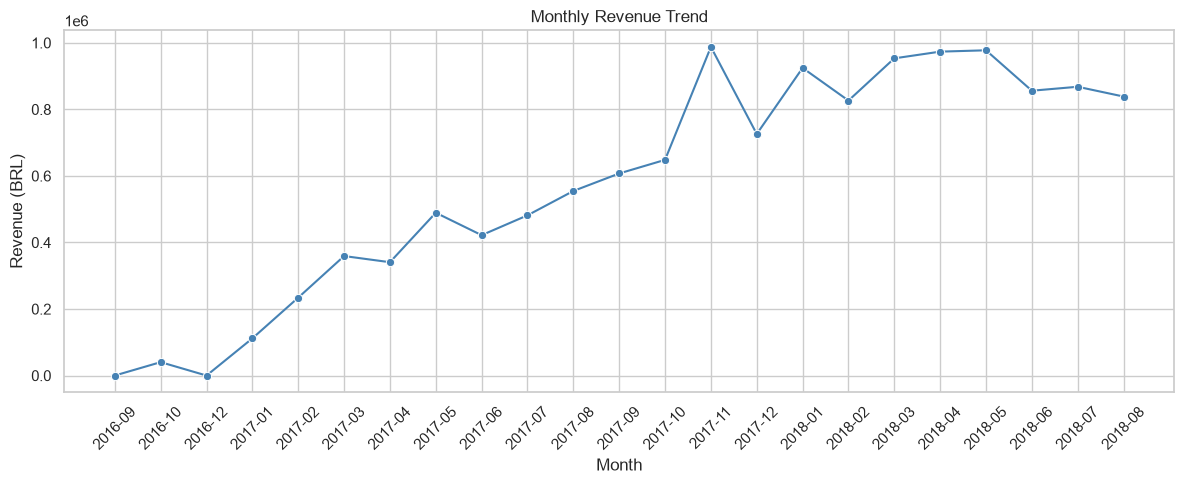

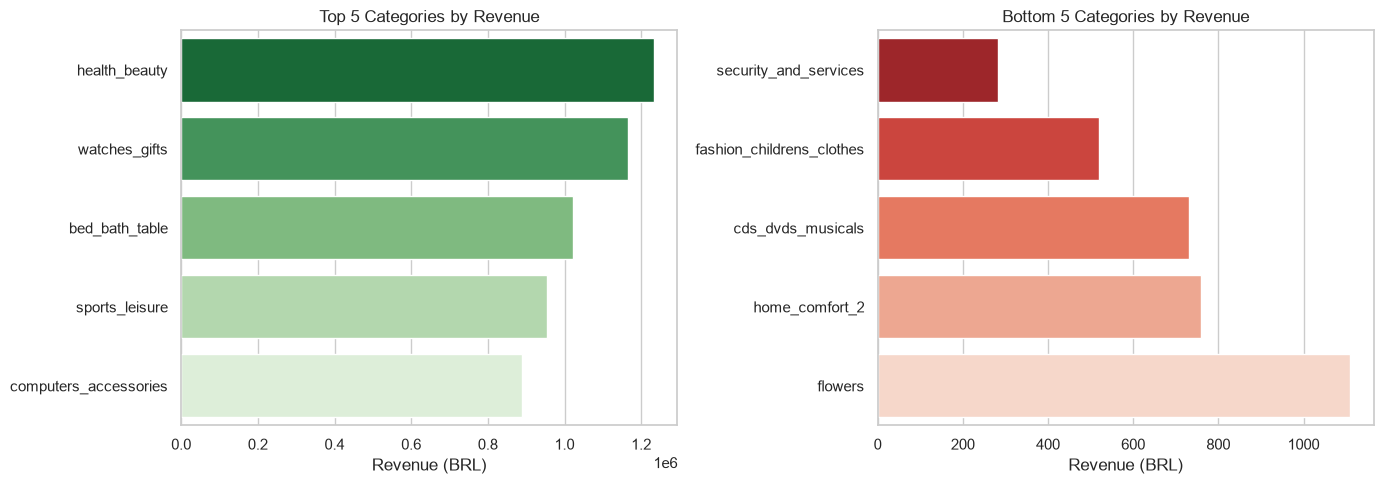

In [83]:

#  [14] Visualization 1: Monthly revenue trend
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_kpis, x="order_month", y="Revenue", marker="o", color="steelblue")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (BRL)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
 
#  [15] Visualization 2: Top 5 and Bottom 5 categories by revenue
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sns.barplot(data=top5_revenue, y="product_category_name_english", x="Revenue",
            hue="product_category_name_english", palette="Greens_r", legend=False, ax=axes[0])
axes[0].set_title("Top 5 Categories by Revenue")
axes[0].set_xlabel("Revenue (BRL)")
axes[0].set_ylabel("")
 
sns.barplot(data=bottom5_revenue, y="product_category_name_english", x="Revenue",
            hue="product_category_name_english", palette="Reds_r", legend=False, ax=axes[1])
axes[1].set_title("Bottom 5 Categories by Revenue")
axes[1].set_xlabel("Revenue (BRL)")
axes[1].set_ylabel("")
 
plt.tight_layout()
plt.show()

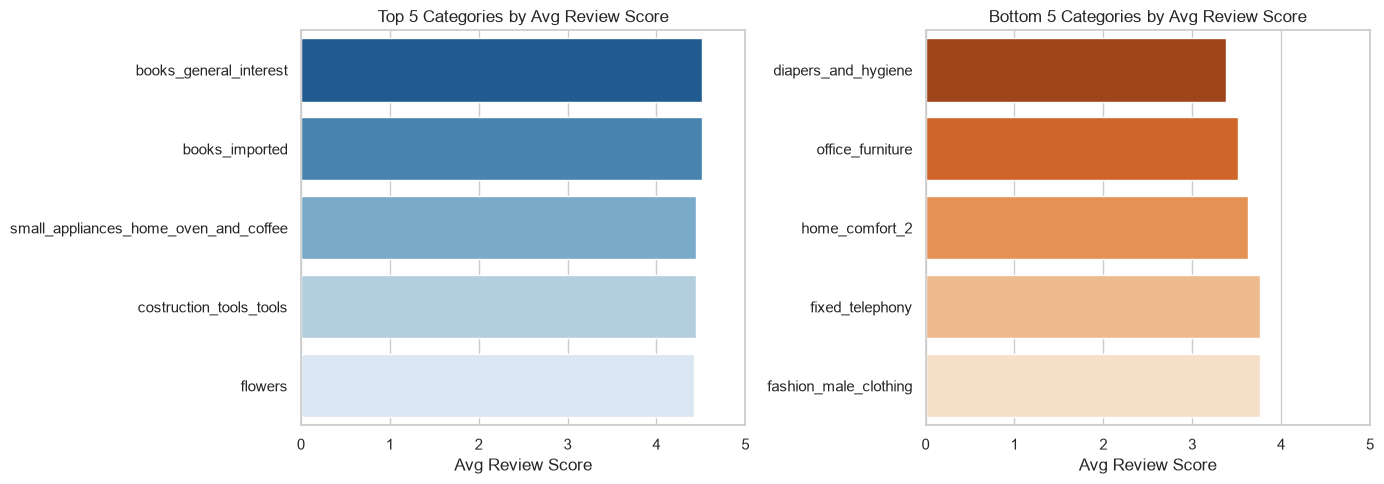

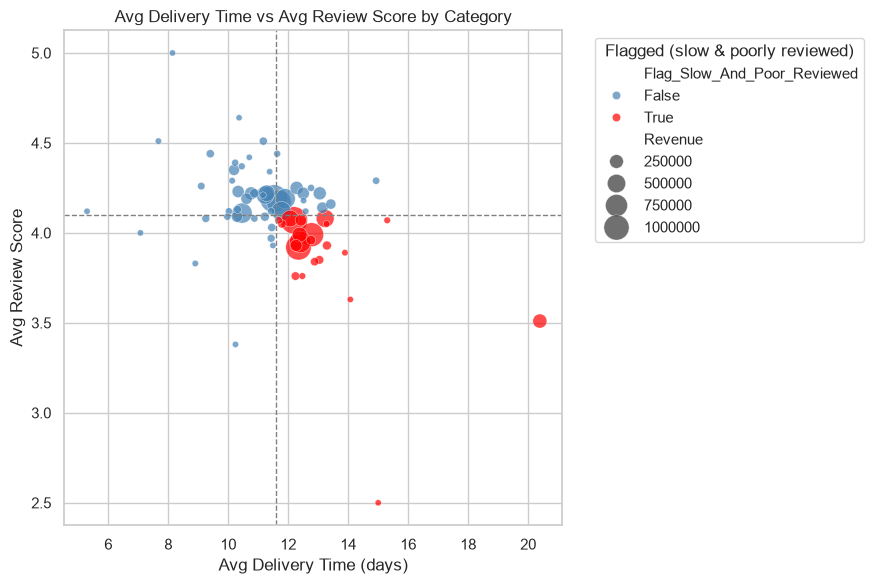

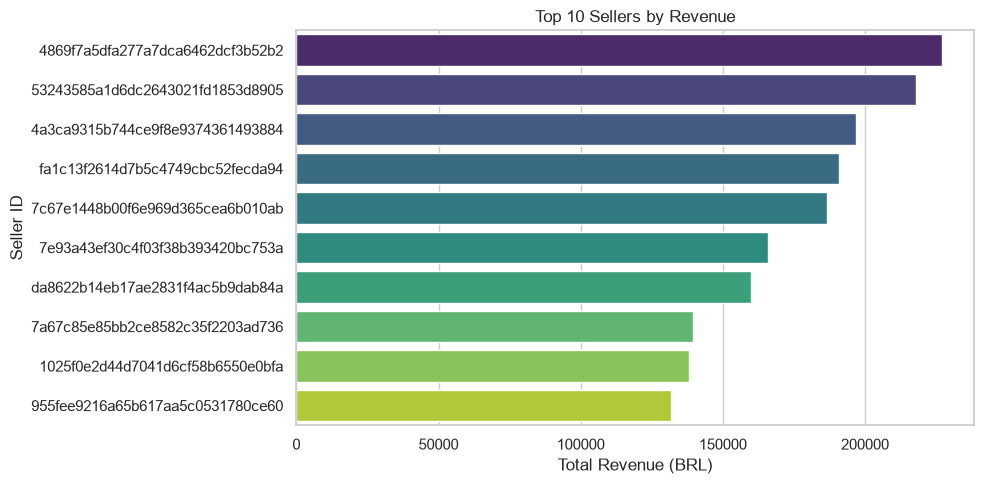

In [84]:
 
#  [16] Visualization 3: Top 5 and Bottom 5 categories by review score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sns.barplot(data=top5_review, y="product_category_name_english", x="Avg_Review_Score",
            hue="product_category_name_english", palette="Blues_r", legend=False, ax=axes[0])
axes[0].set_title("Top 5 Categories by Avg Review Score")
axes[0].set_xlabel("Avg Review Score")
axes[0].set_xlim(0, 5)
axes[0].set_ylabel("")
 
sns.barplot(data=bottom5_review, y="product_category_name_english", x="Avg_Review_Score",
            hue="product_category_name_english", palette="Oranges_r", legend=False, ax=axes[1])
axes[1].set_title("Bottom 5 Categories by Avg Review Score")
axes[1].set_xlabel("Avg Review Score")
axes[1].set_xlim(0, 5)
axes[1].set_ylabel("")
 
plt.tight_layout()
plt.show()
 
#  [17] Visualization 4: Delivery time vs Review score scatter (per category)
avg_review_overall = category_kpis["Avg_Review_Score"].mean()
avg_delivery_overall = category_kpis["Avg_Delivery_Time"].mean()
category_kpis["Flag_Slow_And_Poor_Reviewed"] = (
    (category_kpis["Avg_Delivery_Time"] > avg_delivery_overall) &
    (category_kpis["Avg_Review_Score"] < avg_review_overall)
)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=category_kpis, x="Avg_Delivery_Time", y="Avg_Review_Score",
    size="Revenue", hue="Flag_Slow_And_Poor_Reviewed",
    palette={True: "red", False: "steelblue"}, sizes=(20, 400), alpha=0.7
)
plt.axhline(avg_review_overall, color="gray", linestyle="--", linewidth=1)
plt.axvline(avg_delivery_overall, color="gray", linestyle="--", linewidth=1)
plt.title("Avg Delivery Time vs Avg Review Score by Category")
plt.xlabel("Avg Delivery Time (days)")
plt.ylabel("Avg Review Score")
plt.legend(title="Flagged (slow & poorly reviewed)", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
 
#  [18] Visualization 5: Seller revenue distribution (top sellers)
plt.figure(figsize=(10, 5))
sns.barplot(data=seller_kpis.head(10), y="seller_id", x="Total_Revenue",
            hue="seller_id", palette="viridis", legend=False)
plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Total Revenue (BRL)")
plt.ylabel("Seller ID")
plt.tight_layout()
plt.show()